In [ ]:
# KAGGLE SETUP + DATASET DOWNLOAD

from google.colab import files
files.upload()  # Upload kaggle.json file

import os, shutil

# Move kaggle.json to correct location
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 600)

# Install and download EMNIST dataset
!pip install kaggle
!kaggle datasets download -d crawford/emnist
!unzip emnist.zip -d emnist_data

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/crawford/emnist
License(s): CC0-1.0
100% 1.24G/1.24G [01:21<00:00, 16.4MB/s]

Archive:  emnist.zip
  inflating: emnist_data/emnist-balanced-mapping.txt  
  inflating: emnist_data/emnist-balanced-test.csv  
  inflating: emnist_data/emnist-balanced-train.csv  
  inflating: emnist_data/emnist-byclass-mapping.txt  
  inflating: emnist_data/emnist-byclass-test.csv  
  inflating: emnist_data/emnist-byclass-train.csv  
  inflating: emnist_data/emnist-bymerge-mapping.txt  
  inflating: emnist_data/emnist-bymerge-test.csv  
  inflating: emnist_data/emnist-bymerge-train.csv  
  inflating: emnist_data/emnist-digits-mapping.txt  
  inflating: emnist_data/emnist-digits-test.csv  
  inflating: emnist_data/emnist-digits-train.csv  
  inflating: emnist_data/emnist-letters-mapping.txt  
  inflating: emnist_data/emnist-letters-test.csv  
  inflating: emnist_data/emnist-letters-train.csv  
  inflating: emnist_data/emnist-mnist

In [ ]:
import pandas as pd
import os

path = "emnist_data"

# Load CSV files
# Each row contains: 1 label column + 784 columns of pixel values of a 28x28 image (flattened)
train = pd.read_csv(os.path.join(path, "emnist-letters-train.csv"))
test = pd.read_csv(os.path.join(path, "emnist-letters-test.csv"))

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
import numpy as np

class EMNISTDataset(Dataset):
    # X = pixel values, y = labels
    def __init__(self, df):
        self.X = df.iloc[:, 1:].values  # Extract pixel values (all columns except first)
        self.y = df.iloc[:, 0].values   # Extract labels (first column)

    # Return total number of samples
    def __len__(self):
        return len(self.X)

    # Get one sample (image + label)
    def __getitem__(self, idx):
        img = self.X[idx].reshape(28, 28).astype(np.uint8)  # Reshape flattened 784 pixels → 28x28 image

        img = np.transpose(img)                             # Fix orientation (EMNIST images are rotated by default)

        img = img / 255.0                                   # Normalize pixel values from [0,255] → [0,1]

        img = torch.tensor(img).unsqueeze(0).float()        # Convert to PyTorch tensor and add channel dimension → [1, 28, 28]

        label = int(self.y[idx]) - 1                        # Convert label range from [1–26] → [0–25] for model compatibility

        return img, label


# Create datasets and loaders
train_dataset = EMNISTDataset(train)
test_dataset = EMNISTDataset(test)

# Create DataLoaders to handle batching and iteration
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [ ]:
# SPELLCHECKER SETUP (DICTIONARY)

!pip install pyspellchecker # Install pyspellchecker library (used for correcting predicted words)

from spellchecker import SpellChecker

def load_dictionary():
    print("Loading dictionary (pyspellchecker)...")
    return SpellChecker()

spell = load_dictionary() # Initialize dictionary once and reuse it

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 73.2 MB/s eta 0:00:00
Loading dictionary (pyspellchecker)...


In [ ]:
# CNN MODEL FOR CHARACTER RECOGNITION

import torch.nn as nn

class CharCNN(nn.Module):
    def __init__(self):
        super(CharCNN, self).__init__()

        # Convolution layers → extract features from character images

        # First convolution layer
        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, 1, padding=1),   # Input: [1,28,28] → Output: [32,28,28]
            nn.BatchNorm2d(32),                  # Normalize batch input
            nn.ReLU(),                           # Add non-linearity
            nn.MaxPool2d(2),                     # Downsample → [32,14,14]

            # Second convolution layer
            nn.Conv2d(32, 64, 3, 1, padding=1),  # → [64,14,14]
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),                     # → [64,7,7]

            # Third convolution layer
            nn.Conv2d(64, 128, 3, 1, padding=1), # → [128,7,7]
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)                      # → [128,3,3]
        )

        # Fully connected layers → classify character

        self.fc = nn.Sequential(
            nn.Linear(128 * 3 * 3, 128),         # (FCL1) Flattened input → hidden layer
            nn.ReLU(),

            nn.Dropout(0.3),                     # Prevent overfitting (randomly disables neurons)

            nn.Linear(128, 26)                   # (FCL2) Output layer → 26 classes (a–z)
        )

    # Forward pass

    def forward(self, x):
        x = self.conv(x)                         # Extract features using CNN
        x = x.view(x.size(0), -1)                # Flatten into vector
        return self.fc(x)                        # Classify into one of 26 letters

In [ ]:
import torch

# MODEL INITIALIZATION

model = CharCNN() # Create instance of the CNN model

# Define loss function and optimzer
criterion = nn.CrossEntropyLoss() # CrossEntropyLoss is used for multi-class classification (a–z)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # Use Adam optimizer, lr = learning rate

# MODEL TRAINING

for epoch in range(10): # Train the model for 10 full passes over the dataset
    total_loss = 0      # Track total loss for each epoch

    # Iterate over batches of training data
    for images, labels in train_loader:
        outputs = model(images)             # Forward pass → get model predictions
        loss = criterion(outputs, labels)   # Compute loss (difference between predictions and true labels)

        # Backpropagation
        optimizer.zero_grad()      # Clear old gradients
        loss.backward()            # Compute gradients
        optimizer.step()           # Update model weights

        total_loss += loss.item()  # Add batch loss to total loss

    print(f"Epoch {epoch+1}, Avg Loss: {total_loss/len(train_loader):.4f}")

# Save trained model weights to file
torch.save(model.state_dict(), "char_model.pth")

Epoch 1, Avg Loss: 0.5291
Epoch 2, Avg Loss: 0.2760
Epoch 3, Avg Loss: 0.2324
Epoch 4, Avg Loss: 0.2072
Epoch 5, Avg Loss: 0.1869
Epoch 6, Avg Loss: 0.1740
Epoch 7, Avg Loss: 0.1621
Epoch 8, Avg Loss: 0.1519
Epoch 9, Avg Loss: 0.1416
Epoch 10, Avg Loss: 0.1332


Overall Accuracy: 0.9340


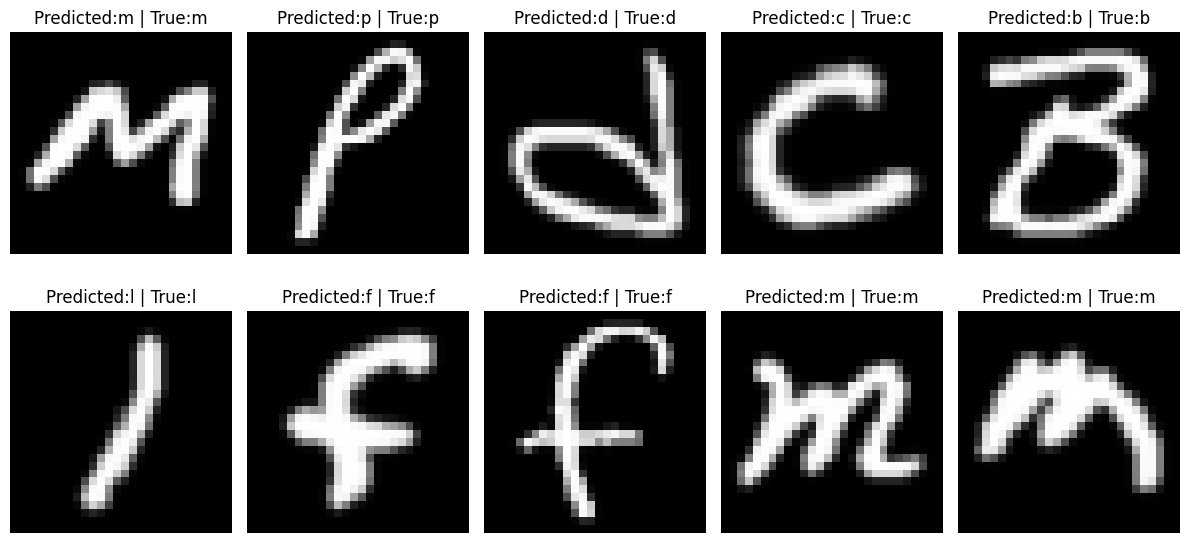

In [ ]:
# MODEL EVALUATION (CHARACTER LEVEL)

import matplotlib.pyplot as plt
import random

# Set model to evaluation mode (disables Dropout and uses learned parameters)
model.eval()

correct = 0
total = 0

# Store predictions and true labels for later analysis (confusion matrix)
all_preds = []
all_labels = []

# Disable gradient computation
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)                                 # Forward pass → get predictions from model
        preds = torch.argmax(outputs, dim=1)                    # Get predicted class (index with highest score)

        # Count correct predictions
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Store predictions and true labels
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

# Compute overall accuracy on test set
accuracy = correct / total
print(f"Overall Accuracy: {accuracy:.4f}")

# VISUAL TESTING (CHARACTER PREDICTIONS)

num_samples = 10
indices = random.sample(range(len(test_dataset)), num_samples)  # Select 10 random samples from test dataset

plt.figure(figsize=(12,6))                                      # Create figure to display images

for i, idx in enumerate(indices):
    img, label = test_dataset[idx]

    # Predict character for single image
    img_input = img.unsqueeze(0)
    output = model(img_input)
    pred = torch.argmax(output, dim=1).item()

    # Convert numeric labels (0–25) → letters (a–z)
    pred_char = chr(pred + ord('a'))
    true_char = chr(label + ord('a'))

    # Display image with predicted and true label
    plt.subplot(2,5,i+1)
    plt.imshow(img.squeeze().numpy(), cmap='gray')
    plt.title(f"Predicted:{pred_char} | True:{true_char}")
    plt.axis('off')

plt.tight_layout()
plt.show()

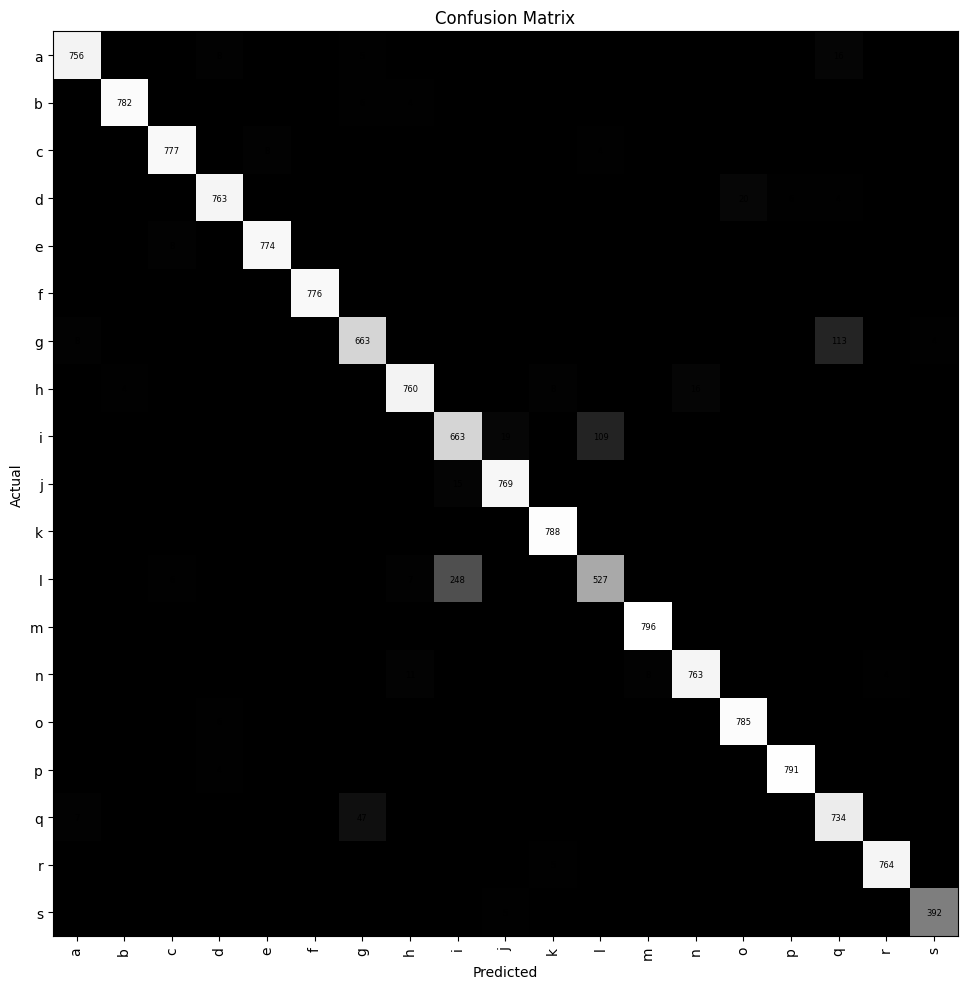

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Compute confusion matrix
labels_present = sorted(set(all_labels))
cm = confusion_matrix(all_labels, all_preds, labels=labels_present)

# Convert numeric class labels (0–25) → corresponding letters (a–z)
letters = [chr(i + ord('a')) for i in labels_present]

# Create figure for visualization and display as a grayscale image
plt.figure(figsize=(10,10))
plt.imshow(cm, cmap='gray')

# Add titles and axis labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# Set axis ticks to corresponding letters
plt.xticks(np.arange(len(letters)), letters, rotation=90)
plt.yticks(np.arange(len(letters)), letters)

# Display how many times each actual letter was predicted as each letter
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha='center', va='center',
                 fontsize=6)

plt.tight_layout()
plt.show()

In [ ]:
# LOADING + UNZIPPING OUR CUSTOM DATASET

from google.colab import files
files.upload()  # upload newDataset.zip
!unzip newDataset.zip -d my_data

Saving newDataset.zip to newDataset.zip
Archive:  newDataset.zip
   creating: my_data/training/
   creating: my_data/training/aisha/
  inflating: my_data/training/aisha/book_1.png  
  inflating: my_data/training/aisha/book_2.png  
  inflating: my_data/training/aisha/brick_1.png  
  inflating: my_data/training/aisha/brick_2.png  
  inflating: my_data/training/aisha/brick_3.png  
  inflating: my_data/training/aisha/brick_4.png  
  inflating: my_data/training/aisha/brick_5.png  
  inflating: my_data/training/aisha/brick_6.png  
  inflating: my_data/training/aisha/fish_1.png  
  inflating: my_data/training/aisha/fish_2.png  
  inflating: my_data/training/aisha/fly_1.png  
  inflating: my_data/training/aisha/fly_2.png  
  inflating: my_data/training/aisha/fly_3.png  
  inflating: my_data/training/aisha/fly_4.png  
  inflating: my_data/training/aisha/fly_5.png  
  inflating: my_data/training/aisha/fly_6.png  
  inflating: my_data/training/aisha/hand_1.png  
  inflating: my_data/training/aish

In [ ]:
# DATASET INSPECTION

import os

train_path = "my_data/training"

# Loop through each folder inside the training directory
for folder in os.listdir(train_path):
    folder_path = os.path.join(train_path, folder)

    # Skip non-folders (like .DS_Store)
    if os.path.isdir(folder_path):
        count = 0

        # Count number of image files in the folder
        for file in os.listdir(folder_path):
            if file.endswith(".png"):
                count += 1

        # Print folder name and number of images inside it
        print(f"{folder}: {count} images")

ela: 46 images
aisha: 46 images
shaikha: 46 images
mariam: 46 images
noorah: 46 images


In [ ]:
# CHARACTER SEGMENTATION FUNCTION

def segment_characters(image_path, show=True):
    import cv2
    import numpy as np
    import matplotlib.pyplot as plt

    img = cv2.imread(image_path)                  # Load image from file
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # Convert to grayscale (simplifies processing)

    # 1. Self-Invert (background fix)
    # If background is light, invert image so text becomes white on black BG
    if gray.mean() > 127.0:
        gray = 255 - gray

    # 2. Gaussian Blur
    # Smooth image to reduce noise before thresholding
    blur = cv2.GaussianBlur(gray, (5,5), 0)

    # 3. Threshold
    # Convert image to black & white using Otsu's method
    _, thresh = cv2.threshold(
        blur, 0, 255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    # 4. Dilation
    # Slightly expand characters to make them more connected
    kernel = np.ones((2, 2), np.uint8)
    thresh = cv2.dilate(thresh, kernel, iterations=1)

    # 5. Find Contours
    # Detect outlines of characters in the image
    contours, _ = cv2.findContours(
        thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )

    # Sort contours from left → right (perserve order of letters in the word)
    contours = sorted(contours, key=lambda b: cv2.boundingRect(b)[0])

    characters = []      # Stores extracted character images
    valid_contours = []  # Stores corresponding contour info
    prev_x = -100        # Track previous x position (for filtering overlaps)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)

        # Ignore very small contours (noise)
        if h > 8:
            # Skip contours that are too close (duplicate detection)
            if abs(x - prev_x) < 8:
                continue

            prev_x = x

            # Crop character region from thresholded image
            char_patch = thresh[y:y+h, x:x+w]

            # RESIZE + CENTER CHARACTER

            # Resize while maintaining aspect ratio
            side = max(h, w)
            scale = 20.0 / side
            rw, rh = int(w * scale), int(h * scale)

            char_resized = cv2.resize(char_patch, (rw, rh))

            # Pad image to make it exactly 28x28 (EMNIST format)
            pad_h = (28 - rh) // 2
            pad_w = (28 - rw) // 2

            char_final = cv2.copyMakeBorder(
                char_resized,
                pad_h, 28 - rh - pad_h,
                pad_w, 28 - rw - pad_w,
                cv2.BORDER_CONSTANT, value=0
            )

            # Store processed character
            characters.append(char_final)
            valid_contours.append(cnt)

    # Display segmented characters
    if show:
        plt.figure(figsize=(10,3))
        for i, ch in enumerate(characters):
            plt.subplot(1, len(characters), i+1)
            plt.imshow(ch, cmap='gray')
            plt.axis('off')
        plt.show()

    return characters, valid_contours


Processing: img_30.png


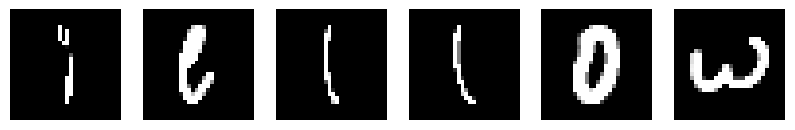

Characters found: 6

Processing: img_29.png


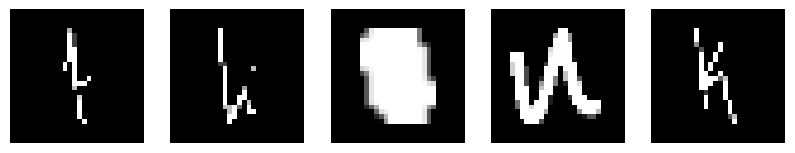

Characters found: 5

Processing: img_11.png


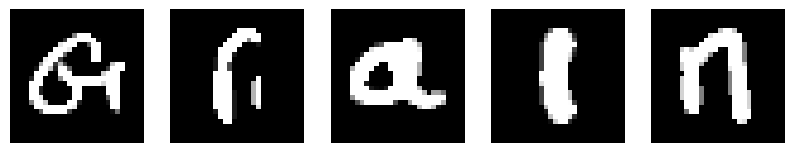

Characters found: 5

Processing: img_12.png


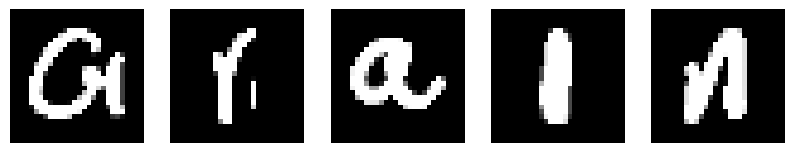

Characters found: 5

Processing: img_08.png


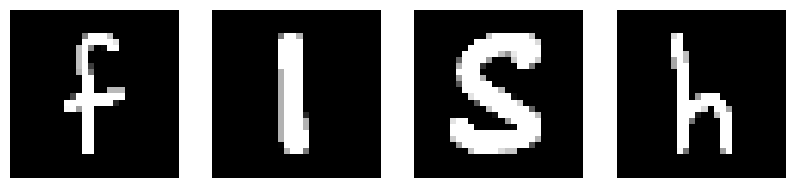

Characters found: 4

Processing: img_07.png


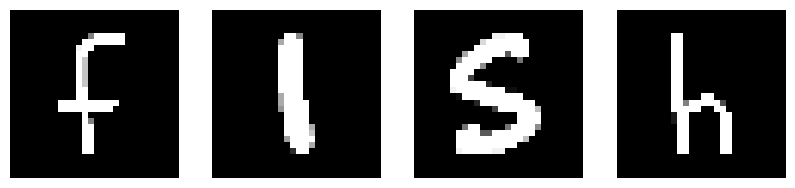

Characters found: 4

Processing: img_16.png


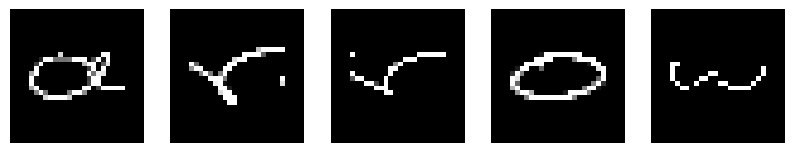

Characters found: 5

Processing: img_24.png


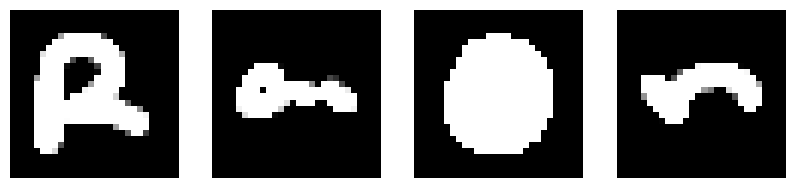

Characters found: 4

Processing: img_13.png


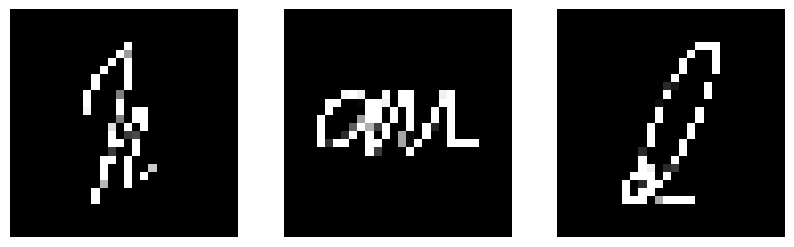

Characters found: 3

Processing: img_02.png


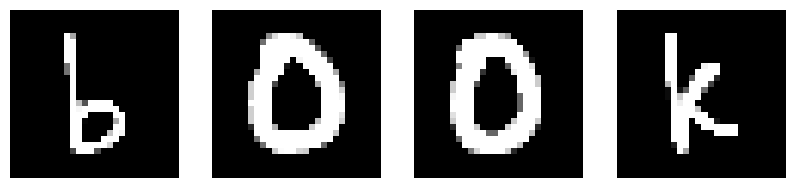

Characters found: 4

Processing: img_01.png


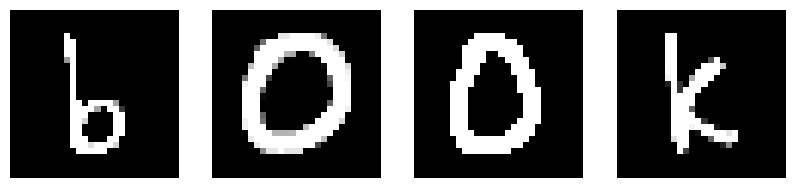

Characters found: 4

Processing: img_14.png


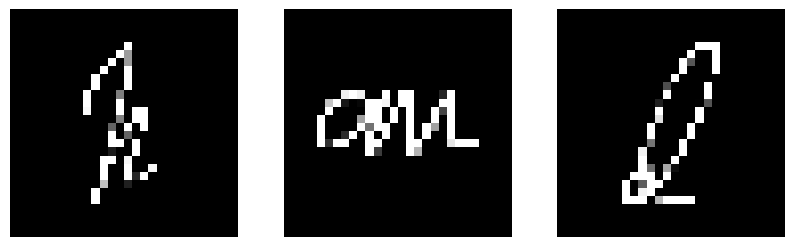

Characters found: 3

Processing: img_19.png


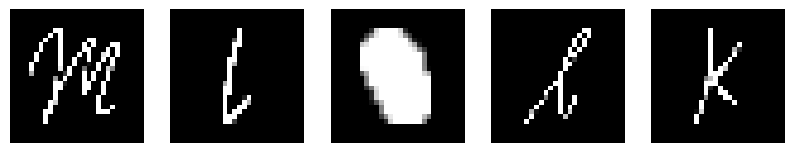

Characters found: 5

Processing: img_09.png


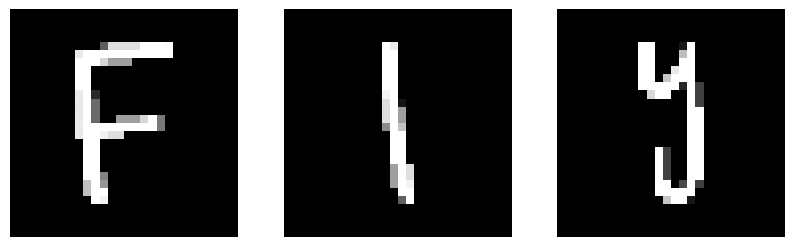

Characters found: 3

Processing: img_25.png


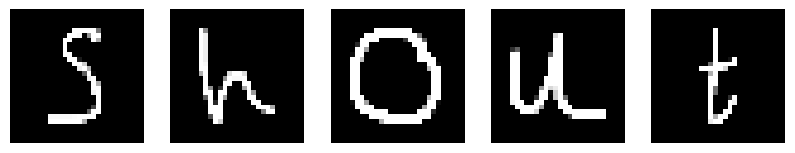

Characters found: 5

Processing: img_27.png


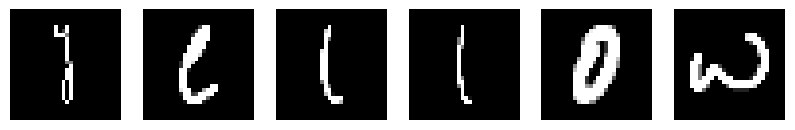

Characters found: 6

Processing: img_05.png


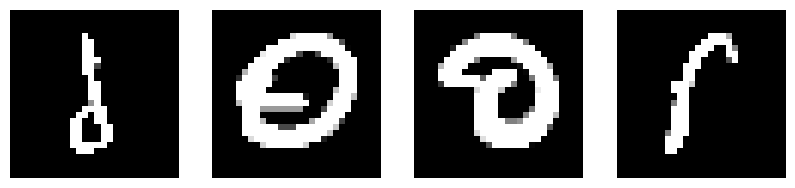

Characters found: 4

Processing: img_21.png


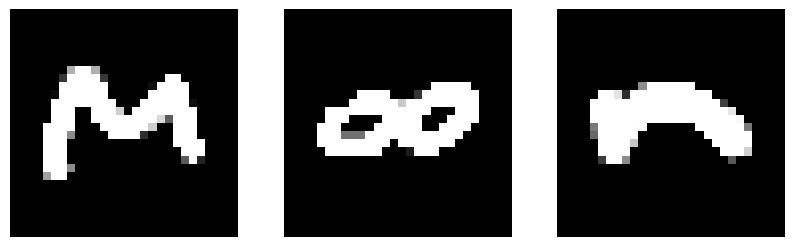

Characters found: 3

Processing: img_18.png


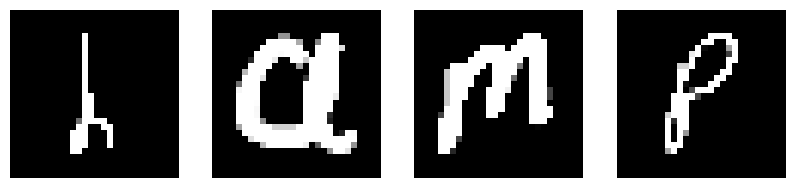

Characters found: 4

Processing: img_03.png


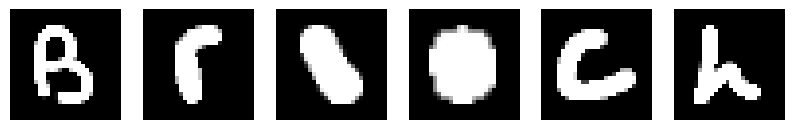

Characters found: 6

Processing: img_06.png


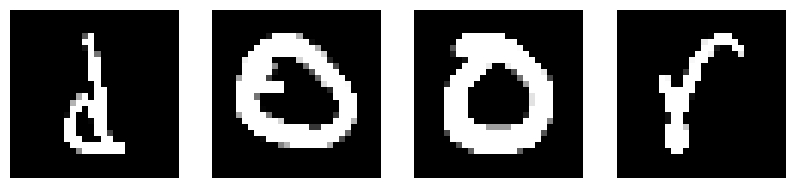

Characters found: 4

Processing: img_10.png


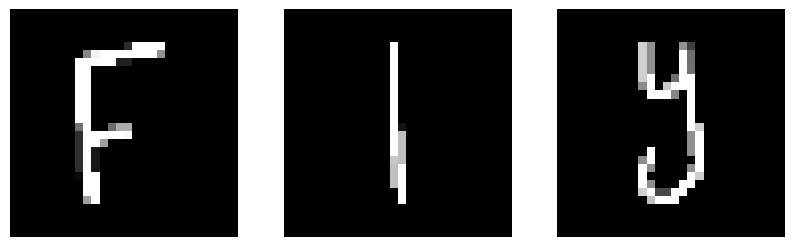

Characters found: 3

Processing: img_20.png


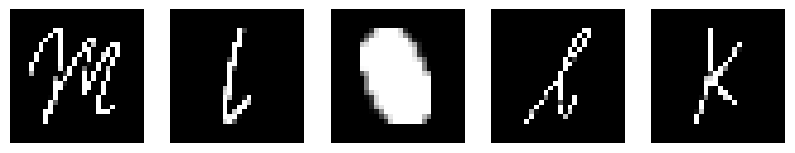

Characters found: 5

Processing: img_23.png


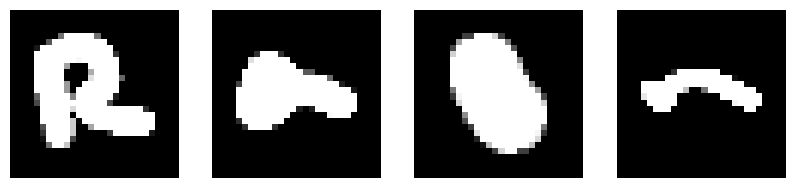

Characters found: 4

Processing: img_26.png


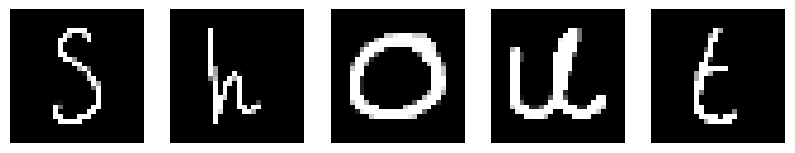

Characters found: 5

Processing: img_17.png


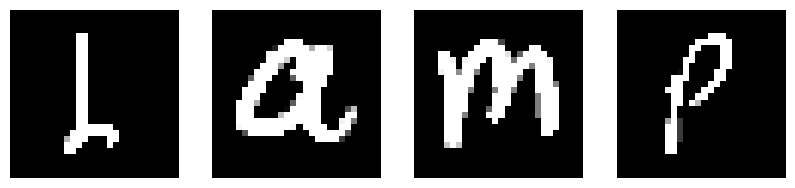

Characters found: 4

Processing: img_15.png


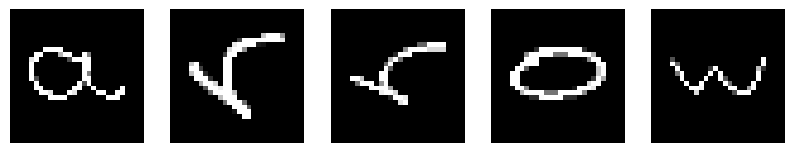

Characters found: 5

Processing: img_22.png


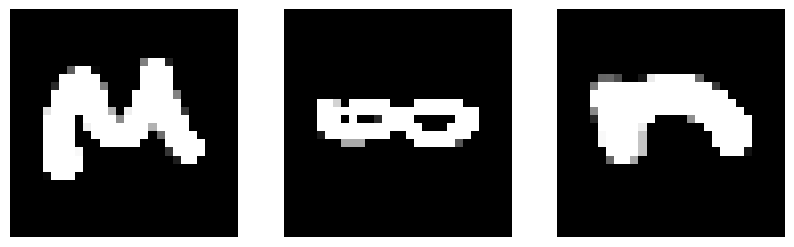

Characters found: 3

Processing: img_04.png


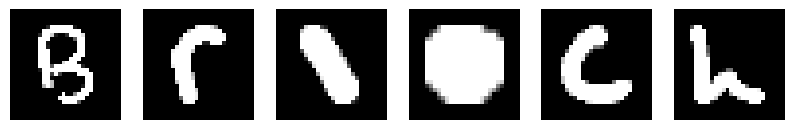

Characters found: 6

Processing: img_28.png


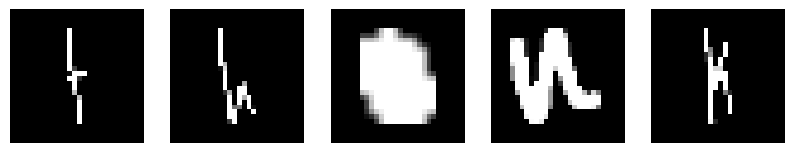

Characters found: 5


In [ ]:
# TEST CHARACTER SEGMENTATION

test_folder = "my_data/testing"

# Loop through each file in the testing folder
for file in os.listdir(test_folder):

    # Process only image files
    if file.endswith(".png"):
        path = os.path.join(test_folder, file)

        print("\nProcessing:", file)

        # Segment image into individual characters
        # Function returns (characters, contours), we only need characters here
        chars, _ = segment_characters(path)

        # Print number of detected characters in the image
        print("Characters found:", len(chars))

In [ ]:
# WORD PREDICTION FUNCTION

def predict_word(model, image_path, use_dictionary=True):

    # STEP 1: SEGMENT IMAGE INTO CHARACTERS
    # Segment the input word image into individual character images + contours
    chars, contours = segment_characters(image_path, show=False)

    word_raw = ""  # Stores raw predicted word (before correction)
    char_confidences = []  # Store confidence for each predicted character

    # STEP 2: COMPUTE CHARACTER SPACING
    # Get bounding boxes for each character (x, y, width, height)
    boxes = [cv2.boundingRect(c) for c in contours]

    # Sort boxes from left → right
    boxes = sorted(boxes, key=lambda b: b[0])

    # Compute horizontal gaps between consecutive characters
    gaps = []
    for i in range(1, len(boxes)):
        prev_x, prev_y, prev_w, prev_h = boxes[i-1]
        curr_x, curr_y, curr_w, curr_h = boxes[i]

        # Distance between current character and previous one
        gap = curr_x - (prev_x + prev_w)
        gaps.append(gap)

    # STEP 3: DETERMINE SPACE THRESHOLD
    # If gap is large → likely a space between words
    if len(gaps) > 0:
        # Adaptive spacing threshold based on this image (handles different handwriting)
        median_gap = np.median(gaps)            # typical gap size
        widths = [w for (_, _, w, _) in boxes]  # character widths
        avg_width = sum(widths) / len(widths)

        space_threshold = max(median_gap * 2.0, avg_width * 0.8)
    else:
        space_threshold = 999                   # No spacing if only one character

    # STEP 4: CHARACTER PREDICTION
    for i, ch in enumerate(chars):
        ch = ch / 255.0  # Normalize image
        tensor = torch.tensor(ch).unsqueeze(0).float()  # Convert to tensor and add channel dimension

        # Ensure shape is [1,1,28,28]
        if tensor.dim() == 3:
            tensor = tensor.unsqueeze(0)

        output = model(tensor)                                # Forward pass through model
        probs = torch.nn.functional.softmax(output, dim=1)    # Convert output to probabilities
        confidence, pred = torch.max(probs, dim=1)            # Get predicted class + confidence

        letter = chr(pred.item() + ord('a'))                  # Convert numeric label → character

        word_raw += letter                                    # Append character to word
        char_confidences.append((letter, confidence.item()))  # Store character + confidence

        # Insert space if gap is large
        if i < len(gaps):
            if gaps[i] > space_threshold:
                word_raw += " "

    # STEP 5: DICTIONARY CORRECTION (OPTIONAL)
    final_word = ""                     # Stores the final corrected word

    # Check if dictionary is enabled
    if use_dictionary:
        parts = word_raw.split(" ")     # Split sentence into words
        corrected_parts = []

        # Loop through each word
        for p in parts:
            if not p: continue
            corr = spell.correction(p)  # Correct word using dictionary
            corrected_parts.append(corr if corr else p)  # Use corrected word if available
        final_word = " ".join(corrected_parts)  # Rebuild the sentence

    # If dictionary is not enabled, return raw prediction
    else:
        final_word = word_raw

    # Compute average confidence
    if len(char_confidences) > 0:
        avg_confidence = sum(c for _, c in char_confidences) / len(char_confidences)
    else:
        avg_confidence = 0

    # Return final predicted word, per-character confidence, and overall confidence
    return final_word, char_confidences, avg_confidence

In [ ]:
# Match final (corrected) word with original prediction confidences, lowering confidence for characters that were changed

def align_word_with_confidence(word, char_confidences):

    aligned = []

    for j in range(len(word)):
        if j < len(char_confidences):
            pred_char, conf = char_confidences[j]

            if word[j] == pred_char:
                aligned.append((word[j], conf))
            else:
                aligned.append((word[j], conf * 0.6))
        else:
            aligned.append((word[j], 0.5))

    return aligned

In [ ]:
# PREPARE DATA FOR FINETUNING

training_folder = "my_data/training"

# Lists to store extracted character images and their labels
char_images = []
char_labels = []

# Loop through each folder in training folder
for person in os.listdir(training_folder):
    person_path = os.path.join(training_folder, person)

    # Skip non-folder files
    if not os.path.isdir(person_path):
        continue

    # Skip non-folder files
    for file in os.listdir(person_path):
        if file.endswith(".png"):

            path = os.path.join(person_path, file)

            # Extract word label from filename (for example: "grain_1.png" → "grain")
            word = file.split("_")[0]

            # Segment word image into individual character images
            chars, _ = segment_characters(path, show=False)

            # Use only samples where segmentation is correct
            # (number of detected characters matches word length)
            if len(chars) == len(word):

                # Pair each character image with its correct label
                for ch_img, ch_label in zip(chars, word):
                    char_images.append(ch_img)

                    # Convert character → numeric label (0–25)
                    char_labels.append(ord(ch_label) - ord('a'))

In [ ]:
# CUSTOM DATASET (FOR FINETUNING)

class CustomCharDataset(Dataset):

    # Initialize dataset with preprocessed character images and labels
    def __init__(self, images, labels):
        self.images = images
        self.labels = labels

    # Return total number of samples
    def __len__(self):
        return len(self.images)

    # Get one sample (image + label)
    def __getitem__(self, idx):
        img = self.images[idx] / 255.0                # Normalize pixel values from [0,255] → [0,1]
        img = torch.tensor(img).unsqueeze(0).float()  # Convert to PyTorch tensor and add channel dimension → [1,28,28]
        label = self.labels[idx]                      # Get corresponding label (already in range 0–25)
        return img, label

In [ ]:
# FINETUNING (ADAPT MODEL TO CUSTOM DATA)

# Create dataset and dataloader from segmented character images
custom_dataset = CustomCharDataset(char_images, char_labels)
custom_loader = DataLoader(custom_dataset, batch_size=32, shuffle=True)

# Set model to training mode (enables dropout and updates weights)
model.train()

# Define optimizer (smaller learning rate for fine-tuning)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)

# Loss function for multi-class classification
criterion = nn.CrossEntropyLoss()

# Train model on custom dataset for a few epochs
for epoch in range(3):
    total_loss = 0

    for images, labels in custom_loader:
        outputs = model(images)              # Forward pass
        loss = criterion(outputs, labels)    # Compute loss

        optimizer.zero_grad()                # Clear previous gradients
        loss.backward()                      # Backpropagation (compute gradients)
        optimizer.step()                     # Update weights

        total_loss += loss.item()

    print(f"Fine-tune Epoch {epoch+1}, Loss: {total_loss/len(custom_loader)}")

Fine-tune Epoch 1, Loss: 0.08516539658965736
Fine-tune Epoch 2, Loss: 0.05716655641023455
Fine-tune Epoch 3, Loss: 0.05052694119513035


In [ ]:
# SAVE FINETUNED MODEL
torch.save(model.state_dict(), "char_model_finetuned.pth")

# LOAD FINETUNED MODEL FOR TESTING
model.load_state_dict(torch.load("char_model_finetuned.pth"))

# Set to evaluation mode for inference
model.eval()

CharCNN(
  (conv): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Linear(in_features=1152, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128,

In [ ]:
true_labels = {
    "img_01.png": "book",
    "img_02.png": "book",
    "img_03.png": "brick",
    "img_04.png": "brick",
    "img_05.png": "door",
    "img_06.png": "door",
    "img_07.png": "fish",
    "img_08.png": "fish",
    "img_09.png": "fly",
    "img_10.png": "fly",
    "img_11.png": "grain",
    "img_12.png": "grain",
    "img_13.png": "hand",
    "img_14.png": "hand",
    "img_15.png": "arrow",
    "img_16.png": "arrow",
    "img_17.png": "lamp",
    "img_18.png": "lamp",
    "img_19.png": "milk",
    "img_20.png": "milk",
    "img_21.png": "moon",
    "img_22.png": "moon",
    "img_23.png": "rain",
    "img_24.png": "rain",
    "img_25.png": "shout",
    "img_26.png": "shout",
    "img_27.png": "yellow",
    "img_28.png": "think",
    "img_29.png": "think",
    "img_30.png": "yellow"
}

In [ ]:
# Function to assign color based on confidence level
def get_color(conf):
    if conf >= 0.9:
        return "green"
    elif conf >= 0.7:
        return "orange"
    else:
        return "red"

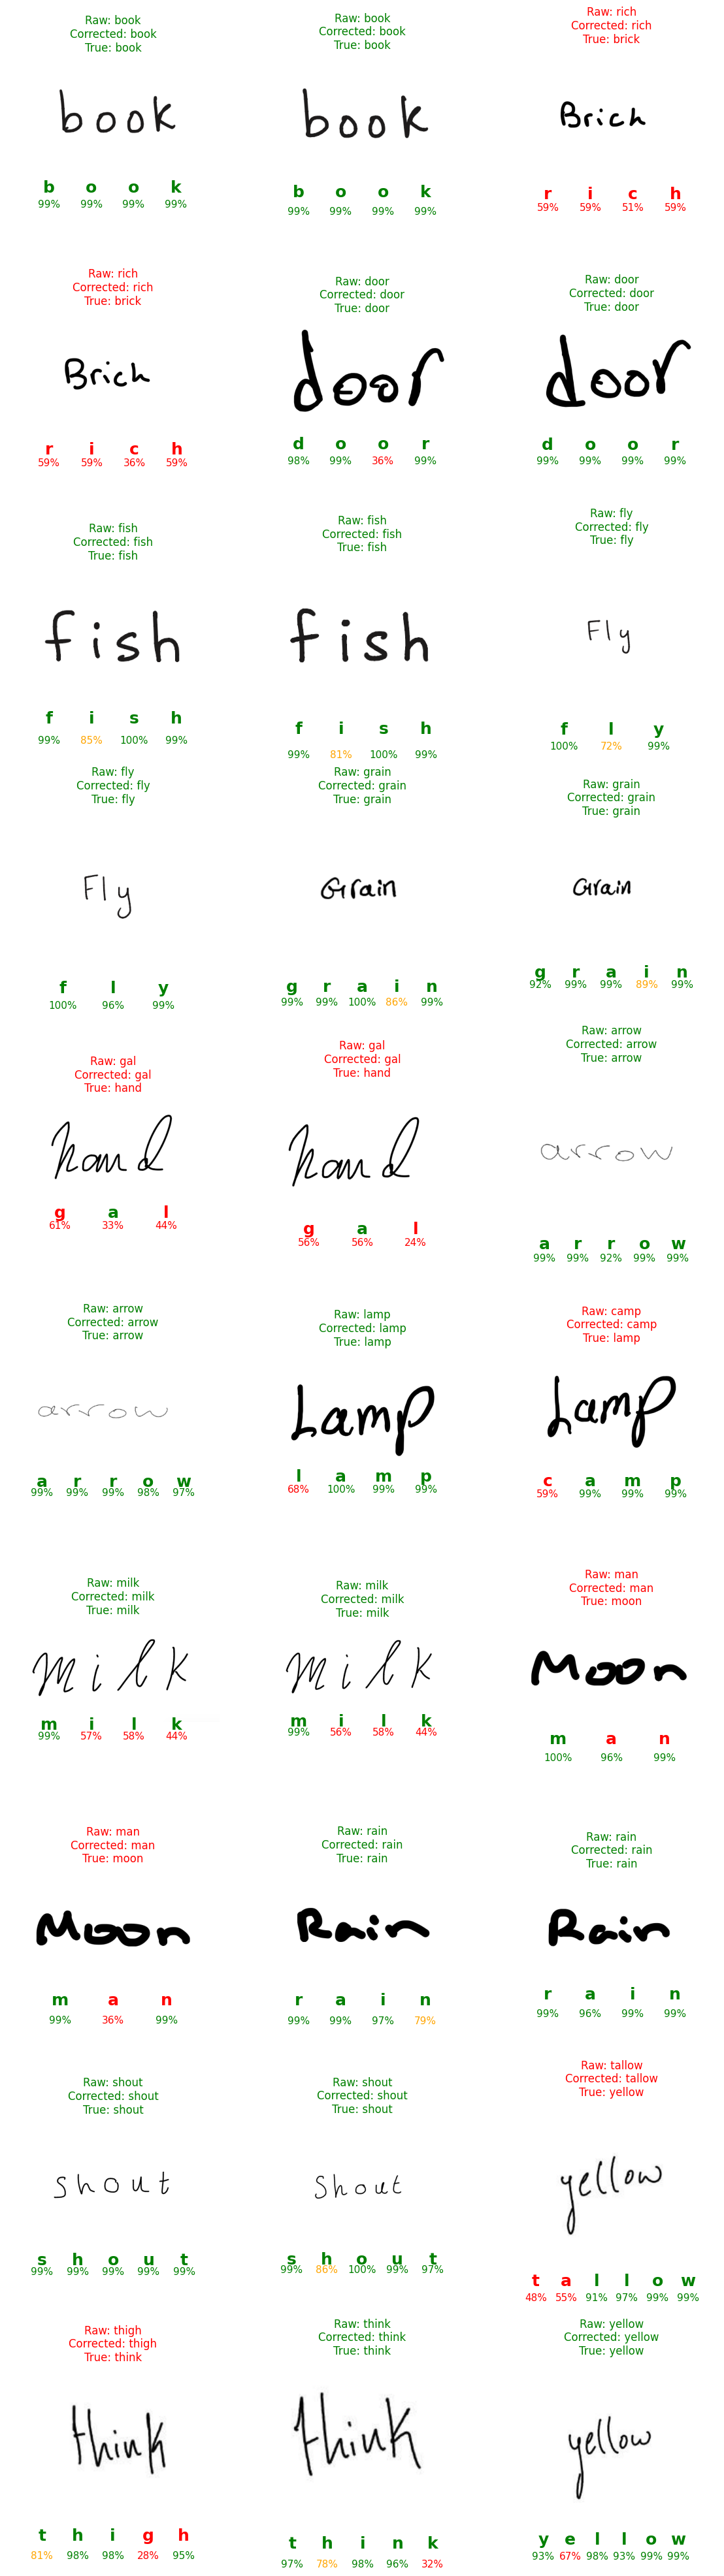


Final Word Accuracy: 21/30 = 0.7000


In [ ]:
# WORD-LEVEL PREDICTION + VISUALIZATION

import matplotlib.pyplot as plt
import cv2

correct = 0
total = 0

test_folder = "my_data/testing"

# Get all image files from the test folder
files = sorted([f for f in os.listdir(test_folder) if f.endswith(".png")])

# Set grid layout for displaying images
cols = 3
rows = (len(files) + cols - 1) // cols
plt.figure(figsize=(12, rows * 4))

# Loop through each test image
for i, file in enumerate(files):
    path = os.path.join(test_folder, file)

    # Load and convert image to RGB (for correct display)
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Predict word + get character confidences
    pred, char_confidences, avg_conf = predict_word(model, path)
    corrected = pred

    # Get true label
    true = true_labels[file]
    true_no_space = true.replace(" ", "")

    # Check if prediction is correct
    is_correct = (corrected == true)
    title_color = "green" if is_correct else "red"

    # Update accuracy counters
    correct += int(is_correct)
    total += 1

    # Display image
    plt.subplot(rows, cols, i+1)
    plt.imshow(img)

    # Show prediction vs actual
    plt.title(
        f"Raw: {pred}\nCorrected: {corrected}\nTrue: {true}",
        color=title_color,
        fontsize=12
    )

    # Align characters with confidence values
    final_chars = align_word_with_confidence(corrected, char_confidences)
    img_width = img.shape[1]
    n_chars = len(final_chars)

    # Dynamically compute spacing between characters (for proper layout)
    spacing = img_width // (n_chars + 1) if n_chars > 1 else img_width // 2

    # DISPLAY CHARACTERS (COLOR-CODED)
    for j, (ch, conf) in enumerate(final_chars):
        x = (j + 1) * spacing

        # Green if correct character, red if incorrect
        if j < len(true_no_space) and ch == true_no_space[j]:
            char_color = "green"
        else:
            char_color = "red"

        plt.text(
            x,
            img.shape[0] + 30,
            ch,
            color=char_color,
            fontsize=18,
            fontweight='bold',
            ha='center'
        )

    # DISPLAY CONFIDENCE VALUES
    for j, (ch, conf) in enumerate(final_chars):
        x = (j + 1) * spacing

        plt.text(
            x,
            img.shape[0] + 70,
            f"{int(conf*100)}%",
            color=get_color(conf),  # Color based on confidence level
            fontsize=11,
            ha='center'
        )

    plt.axis('off')

# Adjust layout and display all images
plt.tight_layout(pad=4.0)
plt.show()

print(f"\nFinal Word Accuracy: {correct}/{total} = {correct/total:.4f}")

In [ ]:
# CHARACTER-LEVEL ACCURACY (WITHIN WORDS)

# Initialize counters
total_chars = 0
correct_chars = 0

# Loop through each test sample
for file in true_labels:

    # Predict word from image
    pred_word, _, _ = predict_word(model, os.path.join(test_folder, file))
    true = true_labels[file]

    # Compare predicted and true characters position-wise
    for p, t in zip(pred_word, true):
        if p == t:
            correct_chars += 1  # Correct character prediction
        total_chars += 1

# Compute character-level accuracy
char_acc = correct_chars / total_chars
print(f"Character Accuracy (Word-Level): {char_acc:.4f}")

Character Accuracy (Word-Level): 0.8333


Saving Screenshot 2026-04-15 093655.png to Screenshot 2026-04-15 093655.png


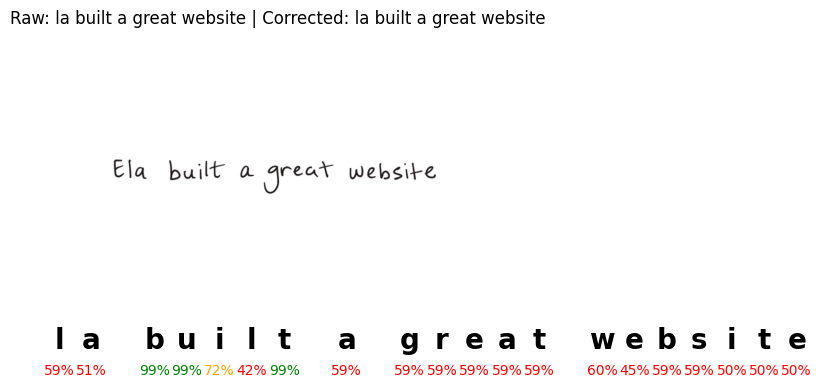

Raw prediction: la built a great website
Corrected sentence: la built a great website
Average confidence: 0.954


In [ ]:
# USER IMAGE PREDICTION + VISUALIZATION (READS SPACES)

from google.colab import files
import cv2
import matplotlib.pyplot as plt

# Upload image from user
uploaded = files.upload()
image_path = list(uploaded.keys())[0]

# Predict word from uploaded image
pred, char_confidences, avg_conf = predict_word(model, image_path)

# HANDLE EMPTY PREDICTIONS (if no text detected or segmentation failed)
if pred.strip() == "" or len(char_confidences) == 0:
    print("⚠️ No text detected")

else:
    # Split predicted sentence into words
    words = pred.split()

    corrected_words = []
    char_index = 0
    structured_chars = []

    # ALIGN WORDS WITH CONFIDENCES
    for word in words:
        length = len(word)

        # Extract corresponding confidences for this word
        word_conf = char_confidences[char_index:char_index + length]

        corrected_words.append(word)

        # Align characters with their confidence values
        structured_chars.append(
            align_word_with_confidence(word, word_conf)
        )

        # Move index forward (+1 accounts for space between words)
        char_index += length + 1

    # Reconstruct full sentence
    corrected_sentence = " ".join(corrected_words)

    # LOAD AND DISPLAY IMAGE
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10,4))
    plt.imshow(img)
    plt.axis('off')

    # Show prediction result
    plt.title(f"Raw: {pred} | Corrected: {corrected_sentence}")

    # DISPLAY CHARACTERS + CONFIDENCE
    x = 50

    letter_spacing = 75   # controls spacing BETWEEN letters (visual only)
    word_spacing = 70     # controls spacing BETWEEN words

    for word in structured_chars:
        for ch, conf in word:

            # Display character
            plt.text(
                x,
                img.shape[0] + 20,
                ch,
                fontsize=20,
                ha='center',
                color='black',
                fontweight='bold'
            )

            # Display confidence below character
            plt.text(
                x,
                img.shape[0] + 80,
                f"{int(conf*100)}%",
                fontsize=10,
                ha='center',
                color=get_color(conf)
            )

            x += letter_spacing   # Move to next character position

        x += word_spacing         # Add extra space between words

    plt.show()

    # PRINT RESULTS
    print("Raw prediction:", pred)
    print("Corrected sentence:", corrected_sentence)
    print("Average confidence:", round(avg_conf, 3))